In [1]:
# AIML Capstone Project - Sales Forecasting

In [ ]:
## Business Problem

Fresh Analytics aims to understand and predict demand for various items across restaurants.  
The objective is to analyze historical sales data and forecast future demand to improve business decisions.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
print("Libraries imported successfully")

Libraries imported successfully


In [1]:
import pandas as pd
print("Working ✅")

Working ✅


In [2]:
import sys
print(sys.executable)

import pandas as pd
print("Working ✅")

c:\Users\athmi\AIML_Capstone_SalesForecast\venv\Scripts\python.exe
Working ✅


In [5]:
import sys
print(sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Working ✅")

c:\Users\athmi\AIML_Capstone_SalesForecast\venv\Scripts\python.exe
Working ✅


In [6]:
restaurants = pd.read_csv("../data/restaurants.csv")
items = pd.read_csv("../data/items.csv")
sales = pd.read_csv("../data/sales.csv")

print("Restaurants shape:", restaurants.shape)
print("Items shape:", items.shape)
print("Sales shape:", sales.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../data/restaurants.csv'

In [7]:
import os
print(os.listdir("../data"))

['items.csv', 'resturants.csv', 'sales.csv']


In [8]:
restaurants = pd.read_csv("../data/resturants.csv")
items = pd.read_csv("../data/items.csv")
sales = pd.read_csv("../data/sales.csv")

print("Restaurants shape:", restaurants.shape)
print("Items shape:", items.shape)
print("Sales shape:", sales.shape)

Restaurants shape: (6, 2)
Items shape: (100, 5)
Sales shape: (109600, 4)


In [9]:
print("Restaurants columns:", restaurants.columns.tolist())
print("Items columns:", items.columns.tolist())
print("Sales columns:", sales.columns.tolist())

print("\nRestaurants head:")
display(restaurants.head())

print("\nItems head:")
display(items.head())

print("\nSales head:")
display(sales.head())

Restaurants columns: ['id', 'name']
Items columns: ['id', 'store_id', 'name', 'kcal', 'cost']
Sales columns: ['date', 'item_id', 'price', 'item_count']

Restaurants head:


,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe



Items head:


,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07



Sales head:


,date,item_id,price,item_count
0,2019-01-01,3,29.22,2.0
1,2019-01-01,4,26.42,22.0
2,2019-01-01,12,4.87,7.0
3,2019-01-01,13,4.18,12.0
4,2019-01-01,16,3.21,136.0


In [10]:
# Convert date column to datetime
sales['date'] = pd.to_datetime(sales['date'])

# Merge sales with items
merged = sales.merge(
    items,
    left_on='item_id',
    right_on='id',
    how='left',
    suffixes=('', '_item')
)

# Merge with restaurants
merged = merged.merge(
    restaurants,
    left_on='store_id',
    right_on='id',
    how='left',
    suffixes=('', '_restaurant')
)

print("Merged shape:", merged.shape)
print("\nMerged columns:")
print(merged.columns.tolist())

display(merged.head())

Merged shape: (109600, 11)

Merged columns:
['date', 'item_id', 'price', 'item_count', 'id', 'store_id', 'name', 'kcal', 'cost', 'id_restaurant', 'name_restaurant']


,date,item_id,price,item_count,id,store_id,name,kcal,cost,id_restaurant,name_restaurant
0,2019-01-01,3,29.22,2.0,3,1,Sweet Fruity Cake,931,29.22,1,Bob's Diner
1,2019-01-01,4,26.42,22.0,4,1,Amazing Steak Dinner with Rolls,763,26.42,1,Bob's Diner
2,2019-01-01,12,4.87,7.0,12,1,Fantastic Sweet Cola,478,4.87,1,Bob's Diner
3,2019-01-01,13,4.18,12.0,13,1,Sweet Frozen Soft Drink,490,4.18,1,Bob's Diner
4,2019-01-01,16,3.21,136.0,16,1,Frozen Milky Smoothy,284,3.21,1,Bob's Diner


In [11]:
# Rename columns clearly
merged = merged.rename(columns={
    'id': 'item_master_id',
    'name': 'item_name',
    'id_restaurant': 'restaurant_id',
    'name_restaurant': 'restaurant_name'
})

# Create revenue column
merged['revenue'] = merged['price'] * merged['item_count']

# Final dataset
final_df = merged[[
    'date',
    'item_id',
    'item_name',
    'price',
    'item_count',
    'kcal',
    'cost',
    'store_id',
    'restaurant_name',
    'revenue'
]].copy()

print("Final dataset shape:", final_df.shape)
display(final_df.head())

Final dataset shape: (109600, 10)


,date,item_id,item_name,price,item_count,kcal,cost,store_id,restaurant_name,revenue
0,2019-01-01,3,Sweet Fruity Cake,29.22,2.0,931,29.22,1,Bob's Diner,58.44
1,2019-01-01,4,Amazing Steak Dinner with Rolls,26.42,22.0,763,26.42,1,Bob's Diner,581.24
2,2019-01-01,12,Fantastic Sweet Cola,4.87,7.0,478,4.87,1,Bob's Diner,34.09
3,2019-01-01,13,Sweet Frozen Soft Drink,4.18,12.0,490,4.18,1,Bob's Diner,50.16
4,2019-01-01,16,Frozen Milky Smoothy,3.21,136.0,284,3.21,1,Bob's Diner,436.56


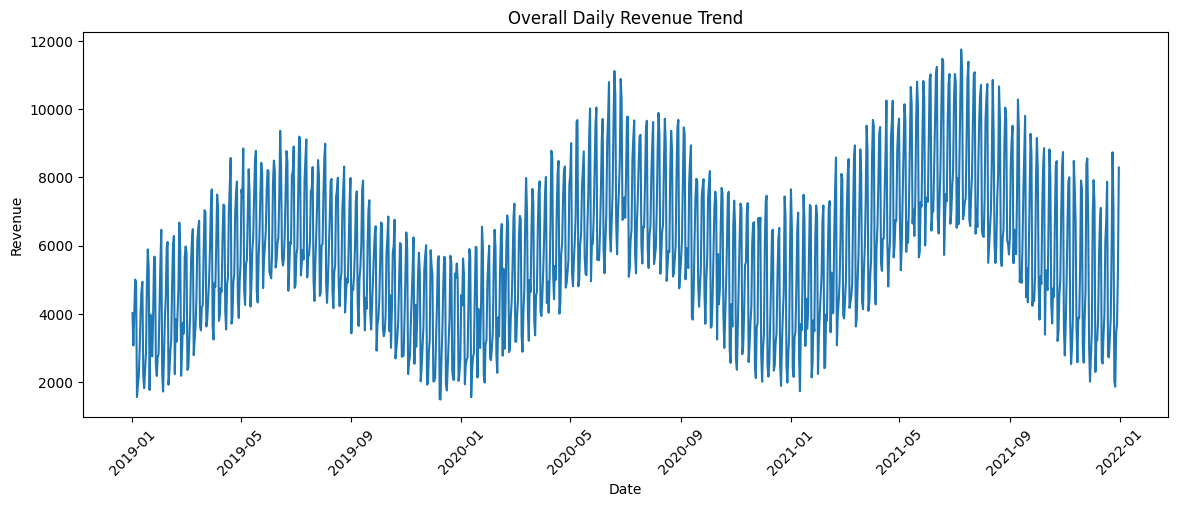

In [12]:
daily_sales = final_df.groupby('date')['revenue'].sum().reset_index()

plt.figure(figsize=(14,5))
plt.plot(daily_sales['date'], daily_sales['revenue'])
plt.title("Overall Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()

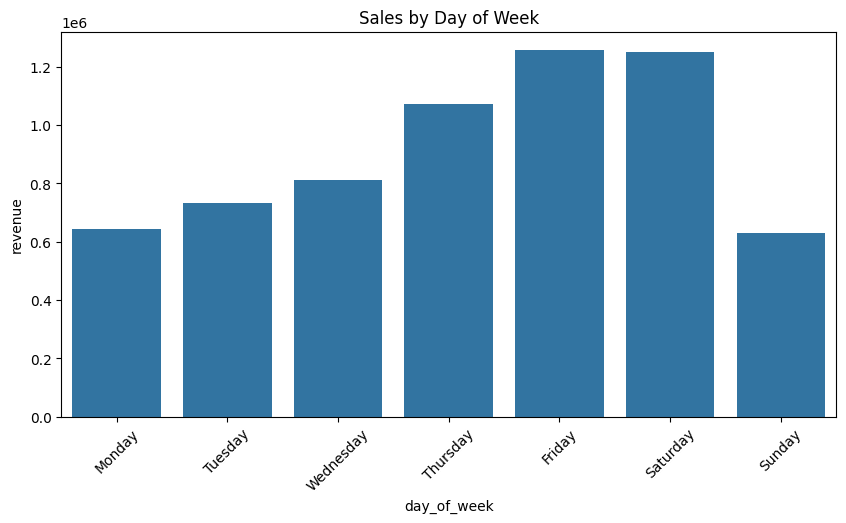

In [13]:
final_df['day_of_week'] = final_df['date'].dt.day_name()

weekday_sales = final_df.groupby('day_of_week')['revenue'].sum().reset_index()

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_sales['day_of_week'] = pd.Categorical(weekday_sales['day_of_week'], categories=order, ordered=True)

weekday_sales = weekday_sales.sort_values('day_of_week')

plt.figure(figsize=(10,5))
sns.barplot(data=weekday_sales, x='day_of_week', y='revenue')
plt.title("Sales by Day of Week")
plt.xticks(rotation=45)
plt.show()

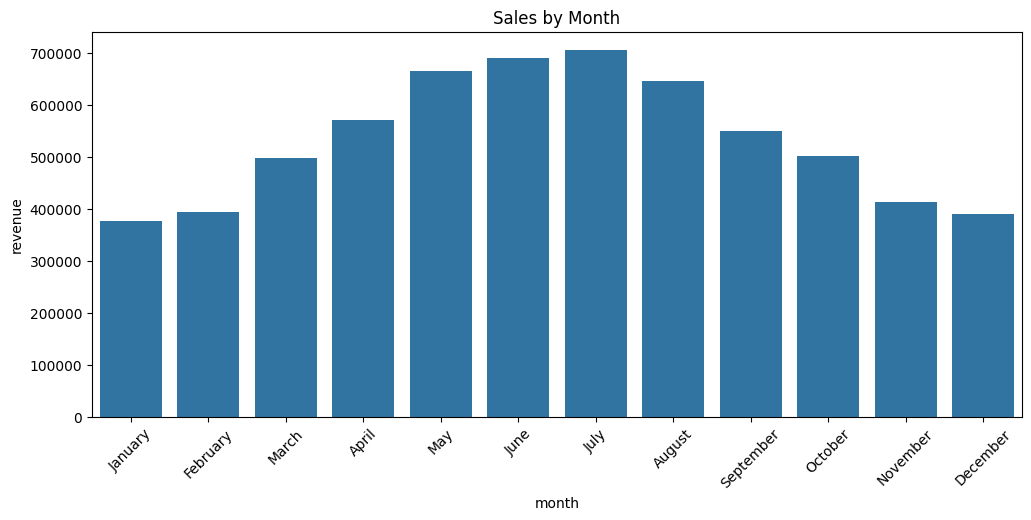

In [14]:
final_df['month'] = final_df['date'].dt.month_name()

monthly_sales = final_df.groupby('month')['revenue'].sum().reset_index()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales['month'] = pd.Categorical(monthly_sales['month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('month')

plt.figure(figsize=(12,5))
sns.barplot(data=monthly_sales, x='month', y='revenue')
plt.xticks(rotation=45)
plt.title("Sales by Month")
plt.show()

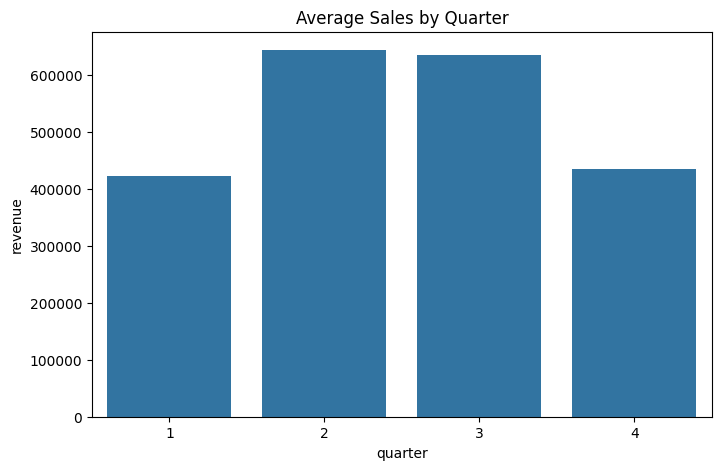

In [15]:
final_df['quarter'] = final_df['date'].dt.quarter
final_df['year'] = final_df['date'].dt.year

quarter_sales = final_df.groupby(['year','quarter'])['revenue'].sum().reset_index()
quarter_avg = quarter_sales.groupby('quarter')['revenue'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=quarter_avg, x='quarter', y='revenue')
plt.title("Average Sales by Quarter")
plt.show()

,restaurant_name,revenue
1,Bob's Diner,6337275.69
3,Fou Cher,27885.37
2,Corner Cafe,16551.43
4,Surfs Up,15651.49
0,Beachfront Bar,3796.20
5,Sweet Shack,2578.27


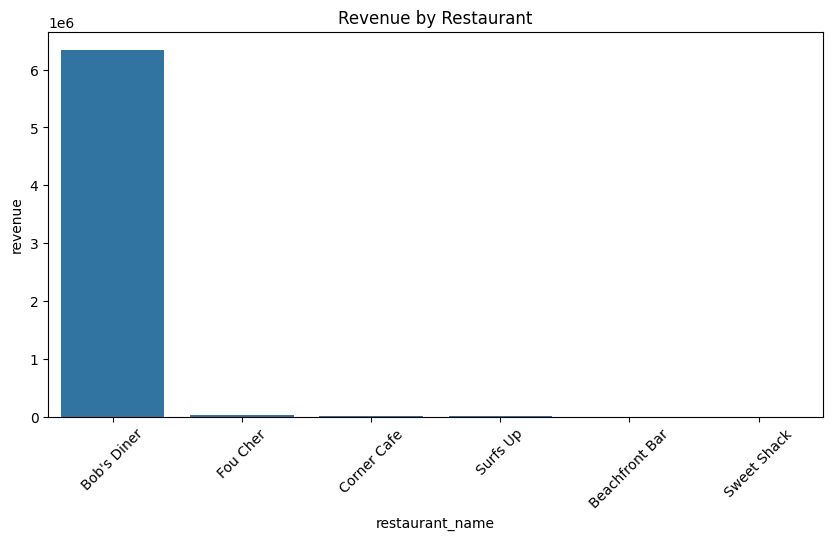

In [16]:
restaurant_sales = final_df.groupby('restaurant_name')['revenue'].sum().reset_index()
restaurant_sales = restaurant_sales.sort_values(by='revenue', ascending=False)

display(restaurant_sales)

plt.figure(figsize=(10,5))
sns.barplot(data=restaurant_sales, x='restaurant_name', y='revenue')
plt.xticks(rotation=45)
plt.title("Revenue by Restaurant")
plt.show()

In [17]:
popular_items = final_df.groupby('item_name')['item_count'].sum().reset_index()
popular_items = popular_items.sort_values(by='item_count', ascending=False)

display(popular_items.head(10))

,item_name,item_count
85,Strawberry Smoothy,236337.0
46,Frozen Milky Smoothy,103263.0
9,Amazing pork lunch,61043.0
64,Mutton Dinner,52772.0
67,Orange Juice,43874.0
22,Blue Ribbon Beef Entree,42774.0
4,Amazing Steak Dinner with Rolls,34439.0
88,Sweet Frozen Soft Drink,27490.0
83,Sea Bass with Vegetables Dinner,23839.0
90,Sweet Lamb Cake,18764.0


In [18]:
store_item = final_df.groupby(['restaurant_name','item_name'])['item_count'].sum().reset_index()

top_items = store_item.loc[store_item.groupby('restaurant_name')['item_count'].idxmax()]

display(top_items)

,restaurant_name,item_name,item_count
1,Beachfront Bar,Fantastic Milky Smoothy,1147.0
25,Bob's Diner,Strawberry Smoothy,236337.0
40,Corner Cafe,Frozen Milky Smoothy,273.0
57,Fou Cher,Blue Ribbon Fruity Vegi Lunch,298.0
85,Surfs Up,Awesome Soft Drink,997.0
92,Sweet Shack,Awesome Smoothy,1692.0


In [19]:
store_volume = final_df.groupby('restaurant_name')['item_count'].sum().reset_index()
store_revenue = final_df.groupby('restaurant_name')['revenue'].sum().reset_index()

compare = store_volume.merge(store_revenue, on='restaurant_name')
display(compare)

,restaurant_name,item_count,revenue
0,Beachfront Bar,1305.0,3796.20
1,Bob's Diner,687527.0,6337275.69
2,Corner Cafe,1310.0,16551.43
3,Fou Cher,1106.0,27885.37
4,Surfs Up,1803.0,15651.49
5,Sweet Shack,1736.0,2578.27


In [20]:
expensive_items = final_df.groupby(['restaurant_name','item_name','kcal'])['price'].max().reset_index()

top_expensive = expensive_items.loc[expensive_items.groupby('restaurant_name')['price'].idxmax()]

display(top_expensive)

,restaurant_name,item_name,kcal,price
5,Beachfront Bar,Sweet Vegi Soft Drink,538,5.70
28,Bob's Diner,Sweet Fruity Cake,931,29.22
52,Corner Cafe,Pike Lunch,653,26.37
57,Fou Cher,Blue Ribbon Fruity Vegi Lunch,881,53.98
91,Surfs Up,Steak Meal,607,26.21
93,Sweet Shack,Blue Ribbon Frozen Milky Cake,636,7.70


In [21]:
## Machine Learning - Sales Forecasting

In [22]:
# Create time-based features
final_df['year'] = final_df['date'].dt.year
final_df['month'] = final_df['date'].dt.month
final_df['day'] = final_df['date'].dt.day
final_df['day_of_week'] = final_df['date'].dt.dayofweek
final_df['quarter'] = final_df['date'].dt.quarter

# Encode restaurant
final_df['restaurant_encoded'] = final_df['restaurant_name'].astype('category').cat.codes

print(final_df.head())

        date  item_id                        item_name  price  item_count  \
0 2019-01-01        3                Sweet Fruity Cake  29.22         2.0   
1 2019-01-01        4  Amazing Steak Dinner with Rolls  26.42        22.0   
2 2019-01-01       12             Fantastic Sweet Cola   4.87         7.0   
3 2019-01-01       13          Sweet Frozen Soft Drink   4.18        12.0   
4 2019-01-01       16             Frozen Milky Smoothy   3.21       136.0   

   kcal   cost  store_id restaurant_name  revenue  day_of_week  month  \
0   931  29.22         1     Bob's Diner    58.44            1      1   
1   763  26.42         1     Bob's Diner   581.24            1      1   
2   478   4.87         1     Bob's Diner    34.09            1      1   
3   490   4.18         1     Bob's Diner    50.16            1      1   
4   284   3.21         1     Bob's Diner   436.56            1      1   

   quarter  year  day  restaurant_encoded  
0        1  2019    1                   1  
1        1

In [23]:
features = [
    'year',
    'month',
    'day',
    'day_of_week',
    'quarter',
    'price',
    'kcal',
    'cost',
    'restaurant_encoded'
]

target = 'revenue'

In [24]:
# Sort by date
final_df = final_df.sort_values('date')

# Create split point
split_date = final_df['date'].max() - pd.DateOffset(months=6)

train = final_df[final_df['date'] <= split_date]
test = final_df[final_df['date'] > split_date]

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (91200, 9)
Test shape: (18400, 9)


In [25]:
lr = LinearRegression()
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [26]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [27]:
xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [28]:
from sklearn.metrics import mean_squared_error
import numpy as np

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print("Linear Regression RMSE:", lr_rmse)
print("Random Forest RMSE:", rf_rmse)
print("XGBoost RMSE:", xgb_rmse)

Linear Regression RMSE: 222.63861167452342
Random Forest RMSE: 71.17859593379531
XGBoost RMSE: 87.1266710934758


In [29]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'RMSE': [lr_rmse, rf_rmse, xgb_rmse]
})

display(results.sort_values('RMSE'))

,Model,RMSE
1,Random Forest,71.178596
2,XGBoost,87.126671
0,Linear Regression,222.638612


In [30]:
Among the three models, Random Forest achieved the lowest RMSE of 71.17, outperforming both XGBoost and Linear Regression. 

Linear Regression performed poorly due to its inability to capture non-linear relationships in the data. XGBoost, although a powerful boosting algorithm, did not outperform Random Forest in this case, likely due to the lack of hyperparameter tuning and the relatively simple structure of the dataset.

Random Forest performed best because it effectively captured non-linear patterns and handled variability in the data without overfitting, making it the most suitable model for this problem.

SyntaxError: invalid syntax (4223845543.py, line 1)

In [31]:
future_dates = pd.date_range(
    start=final_df['date'].max() + pd.Timedelta(days=1),
    periods=365
)

future_df = pd.DataFrame({'date': future_dates})

# Create features
future_df['year'] = future_df['date'].dt.year
future_df['month'] = future_df['date'].dt.month
future_df['day'] = future_df['date'].dt.day
future_df['day_of_week'] = future_df['date'].dt.dayofweek
future_df['quarter'] = future_df['date'].dt.quarter

# Use average values
future_df['price'] = final_df['price'].mean()
future_df['kcal'] = final_df['kcal'].mean()
future_df['cost'] = final_df['cost'].mean()
future_df['restaurant_encoded'] = 0

# Predict using best model (Random Forest)
future_df['predicted_revenue'] = rf.predict(future_df[features])

display(future_df.head())

,date,year,month,day,day_of_week,quarter,price,kcal,cost,restaurant_encoded,predicted_revenue
0,2022-01-01,2022,1,1,5,1,11.7637,536.73,11.7637,0,500.6130
1,2022-01-02,2022,1,2,6,1,11.7637,536.73,11.7637,0,200.2764
2,2022-01-03,2022,1,3,0,1,11.7637,536.73,11.7637,0,155.8590
3,2022-01-04,2022,1,4,1,1,11.7637,536.73,11.7637,0,207.5826
4,2022-01-05,2022,1,5,2,1,11.7637,536.73,11.7637,0,215.7864


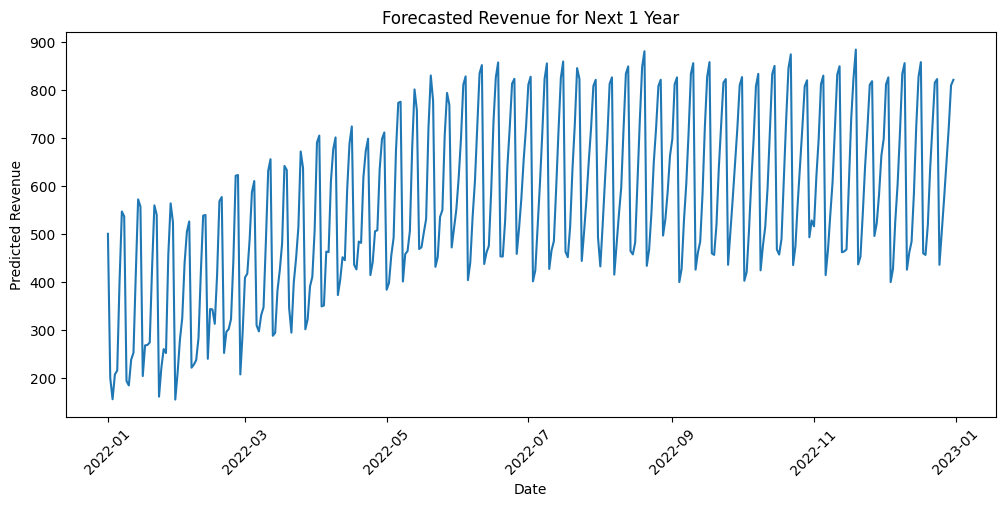

In [32]:
plt.figure(figsize=(12,5))
plt.plot(future_df['date'], future_df['predicted_revenue'])
plt.title("Forecasted Revenue for Next 1 Year")
plt.xlabel("Date")
plt.ylabel("Predicted Revenue")
plt.xticks(rotation=45)
plt.show()

In [ ]:
## Conclusion

In this project, we analyzed sales data across multiple restaurants and built predictive models to forecast future demand.

Exploratory data analysis revealed patterns across days, months, and restaurants. Machine learning models including Linear Regression, Random Forest, and XGBoost were trained and evaluated using RMSE.

Random Forest achieved the best performance with the lowest RMSE, indicating its effectiveness in capturing non-linear relationships in the data. This model was used to forecast future revenue for the next year.

The insights from this project can help businesses optimize inventory, staffing, and operational planning.